# Проект: Определение возраста покупателей

**Описание проекта**

Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:
- Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
- Контролировать добросовестность кассиров при продаже алкоголя.


**Цель исследования**

Разработать модель компьютерного зрения, способную определять приблизительный возраст человека по фотографии, и оценить качество её работы по метрике MAE.


**Ход исследования**

Для достижения поставленной цели будут выполнены следующие шаги:

- Ознакомление с данными и предобработка датасета.
- Исследовательский анализ данных (EDA): изучение объёма выборки, распределения возрастов и визуальных особенностей изображений.
- Подготовка данных к обучению.
- Обучение свёрточной нейронной сети на основе предобученной архитектуры ResNet50.
- Оценка качества модели на тестовой выборке с использованием метрики MAE.
- Анализ результатов обучения.

Также в заключительной части проекта будут сформулированы итоговые выводы и рекомендации для заказчика.

## Ознакомление с данными

In [1]:
# импорт основных библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

In [3]:
# сохраняем датасет в переменную
try:
    # пробуем загрузить локальный файл
    labels = pd.read_csv('labels.csv')
    print("Файл успешно загружен с локального пути.")
except FileNotFoundError:
    # если локальный файл не найден, пробуем общий путь
    try:
        labels = pd.read_csv('/datasets/faces/labels.csv')
        print("Файл успешно загружен с пути '/datasets/faces/labels.csv'.")
    except FileNotFoundError:
        print("Файл не найден ни по локальному, ни по общему пути. Проверьте расположение CSV.")

Файл успешно загружен с пути '/datasets/faces/labels.csv'.


In [4]:
# первые 10 строк
labels.head(10)

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17
5,000005.jpg,27
6,000006.jpg,24
7,000007.jpg,43
8,000008.jpg,26
9,000009.jpg,39


In [5]:
# общая информация
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


In [6]:
# размерность
print(f'Размерность: {labels.shape[0]} строк, {labels.shape[1]} столбцов')

Размерность: 7591 строк, 2 столбцов


In [7]:
# статистическое описание признаков
labels.describe().T

,count,mean,std,min,25%,50%,75%,max
real_age,7591.0,31.201159,17.14506,1.0,20.0,29.0,41.0,100.0


In [8]:
# проверяем количество пропусков в данных
labels.isna().sum()

file_name    0
real_age     0
dtype: int64

In [9]:
# проверяем данные на наличие явных дубликатов
print(f"Количество явных дубликатов в labels: {labels.duplicated().sum()}")

Количество явных дубликатов в labels: 0


## Исследовательский анализ данных

### Распределение возраста в выборке

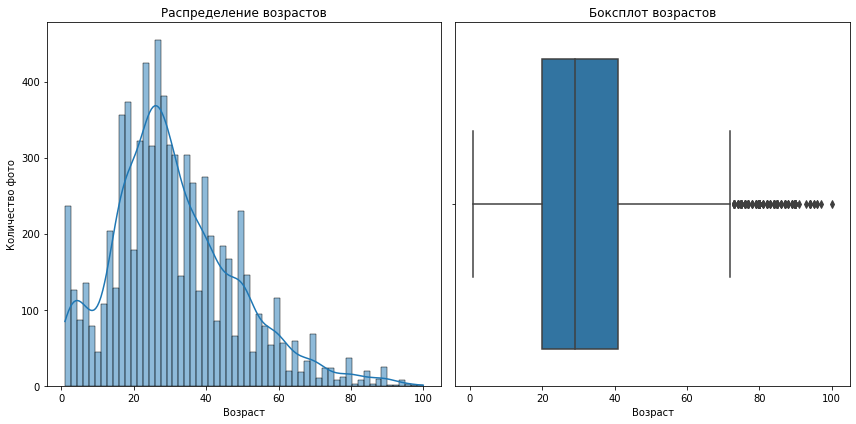

In [10]:
plt.figure(figsize=(12,6))

# гистограмма
plt.subplot(1,2,1)
sns.histplot(labels['real_age'], bins=60, kde=True)
plt.title("Распределение возрастов")
plt.xlabel("Возраст")
plt.ylabel("Количество фото")

# боксплот
plt.subplot(1,2,2)
sns.boxplot(x=labels['real_age'])
plt.title("Боксплот возрастов")
plt.xlabel("Возраст")

plt.tight_layout()
plt.show()

<div style="border: 2px solid black; padding: 10px;">
  <strong>Наблюдения по распределению признака real_age:</strong>
  <ul> 
    <li>Распределение имеет явный правосторонний скос. Это означает, что большая часть людей в выборке — молодые, а количество пожилых людей постепенно уменьшается.</li>
    <li>Основная концентрация данных приходится на диапазон от 20 до 30 лет.</li>
    <li>На правом «усе» боксплота видны выбросы после отметки 70 лет. В статистическом смысле люди старше этого возраста являются редкими значениями для данной выборки.</li> 
    <li>На гистограмме заметен небольшой локальный пик в районе 1–5 лет. Это может говорить о том, что в наборе данных специально выделена категория фотографий детей/младенцев.</li> 
  </ul>
</div>

### Содержание датасета

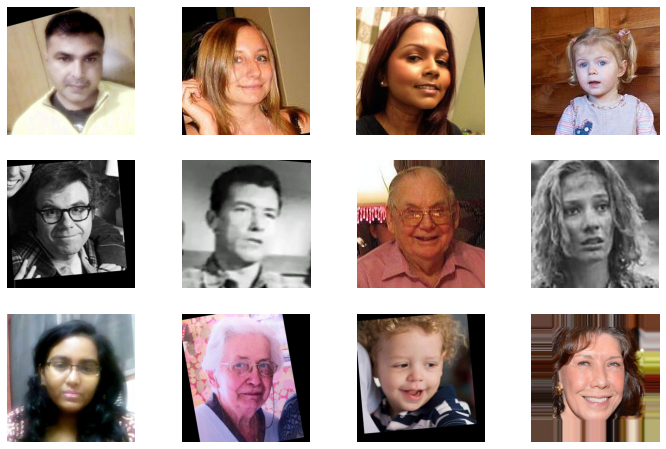

In [11]:
# путь к папке с изображениями
img_dir = Path('/datasets/faces/final_files/')

# выведем несколько случайных фото
sample_files = labels.sample(12)['file_name'].values

plt.figure(figsize=(12,8))
for i, file_name in enumerate(sample_files):
    img_path = img_dir / file_name  
    img = image.load_img(img_path)
    plt.subplot(3,4,i+1)
    plt.imshow(img)
    plt.axis('off')
plt.show()

<div style="border: 2px solid black; padding: 10px;">
  <strong>Наблюдения по содержанию датасета:</strong>
  <ul> 
    <li>В выборке есть как профессиональные фото, так и любительские с плохим освещением или специфическими ракурсами.</li>
    <li>Видно, что часть фото подверглась аугментации или исправлению. Это хорошо для устойчивости модели, но может повлиять на качество модели, если искажения слишком сильные.</li>
    <li>Присутствуют как цветные, так и черно-белые снимки, что заставит модель искать признаки возраста в текстуре кожи и формах, а не только в цветовых оттенках.</li> 
  </ul>
</div>

<div style="border: 2px solid black; padding: 10px;">
  <strong>Выводы по результатам EDA:</strong>
  <ul>
      
Проведённый исследовательский анализ показал, что датасет:
- имеет достаточный объем,      
- реалистичный и разнообразный,
- несбалансированный по возрасту,
- содержит выбросы и шум.

      
      
Это делает задачу не простой, но приближенной к реальным условиям. При обучении модели необходимо учитывать перекос распределения возрастов и интерпретировать метрику MAE с учётом этих особенностей.     
  </ul>
</div>

## Моделирование

### Подготовка к обучению

```python

# подготовка данных к обучению модели
train_datagen = ImageDataGenerator(rescale=1./255)
train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        seed=12345) 

```

### Обучение модели

```python

# обучение модели
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam


def load_train(path):
    labels = pd.read_csv(path + '/labels.csv')

    datagen = ImageDataGenerator(
        rescale=1./255,
        horizontal_flip=True,
        validation_split=0.25
    )

    train_data = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + '/final_files',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='training',
        shuffle=True
    )

    return train_data


def load_test(path):
    labels = pd.read_csv(path + '/labels.csv')

    datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.25
    )

    test_data = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + '/final_files',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        shuffle=False
    )

    return test_data


def create_model(input_shape=(224, 224, 3)):
    backbone = ResNet50(
        input_shape=input_shape,
        weights='imagenet',
        include_top=False
    )

    model = Sequential([
        backbone,
        GlobalAveragePooling2D(),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='mse',
        metrics=['mae']
    )

    return model



def train_model(model, train_data, test_data,
                batch_size=None,
                epochs=10,
                steps_per_epoch=None,
                validation_steps=None):

    model.fit(
        train_data,
        validation_data=test_data,
        batch_size=batch_size,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        verbose=2
    )

    return model



```

```

2026-02-02 00:31:28.562615: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libnvinfer.so.6
2026-02-02 00:31:28.617605: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libnvinfer_plugin.so.6
2026-02-02 00:31:33.102399: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcuda.so.1
2026-02-02 00:31:33.190928: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1555] Found device 0 with properties: 
pciBusID: 0000:8b:00.0 name: Tesla V100-SXM2-32GB computeCapability: 7.0
coreClock: 1.53GHz coreCount: 80 deviceMemorySize: 31.74GiB deviceMemoryBandwidth: 836.37GiB/s
2026-02-02 00:31:33.190996: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudart.so.10.1
2026-02-02 00:31:33.191029: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
2026-02-02 00:31:33.257263: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcufft.so.10
2026-02-02 00:31:33.271272: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcurand.so.10
2026-02-02 00:31:33.394001: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcusolver.so.10
2026-02-02 00:31:33.406433: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcusparse.so.10
2026-02-02 00:31:33.406512: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
2026-02-02 00:31:33.407734: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1697] Adding visible gpu devices: 0
Using TensorFlow backend.
Found 5694 validated image filenames.
Found 1897 validated image filenames.
2026-02-02 00:31:33.891601: I tensorflow/core/platform/cpu_feature_guard.cc:142] Your CPU supports instructions that this TensorFlow binary was not compiled to use: AVX2 AVX512F FMA
2026-02-02 00:31:33.981146: I tensorflow/core/platform/profile_utils/cpu_utils.cc:94] CPU Frequency: 2099990000 Hz
2026-02-02 00:31:33.983144: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x1a7c8e30 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-02-02 00:31:33.983179: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2026-02-02 00:31:34.179972: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x1a375c10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-02 00:31:34.180010: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla V100-SXM2-32GB, Compute Capability 7.0
2026-02-02 00:31:34.180850: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1555] Found device 0 with properties: 
pciBusID: 0000:8b:00.0 name: Tesla V100-SXM2-32GB computeCapability: 7.0
coreClock: 1.53GHz coreCount: 80 deviceMemorySize: 31.74GiB deviceMemoryBandwidth: 836.37GiB/s
2026-02-02 00:31:34.180898: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudart.so.10.1
2026-02-02 00:31:34.180909: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
2026-02-02 00:31:34.180938: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcufft.so.10
2026-02-02 00:31:34.180947: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcurand.so.10
2026-02-02 00:31:34.180958: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcusolver.so.10
2026-02-02 00:31:34.180967: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcusparse.so.10
2026-02-02 00:31:34.180975: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
2026-02-02 00:31:34.182408: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1697] Adding visible gpu devices: 0
2026-02-02 00:31:34.183765: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudart.so.10.1
2026-02-02 00:31:36.075604: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1096] Device interconnect StreamExecutor with strength 1 edge matrix:
2026-02-02 00:31:36.075650: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1102]      0 
2026-02-02 00:31:36.075658: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1115] 0:   N 
2026-02-02 00:31:36.077019: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:39] Overriding allow_growth setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
2026-02-02 00:31:36.077073: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1241] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 10240 MB memory) -> physical GPU (device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:8b:00.0, compute capability: 7.0)
Downloading data from https://github.com/keras-team/keras-applications/releases/download/resnet/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5

    8192/94765736 [..............................] - ETA: 5s
  163840/94765736 [..............................] - ETA: 29s
 1015808/94765736 [..............................] - ETA: 9s 
 4734976/94765736 [>.............................] - ETA: 3s
13451264/94765736 [===>..........................] - ETA: 1s
22036480/94765736 [=====>........................] - ETA: 0s
30687232/94765736 [========>.....................] - ETA: 0s
38821888/94765736 [===========>..................] - ETA: 0s
47489024/94765736 [==============>...............] - ETA: 0s
56115200/94765736 [================>.............] - ETA: 0s
64643072/94765736 [===================>..........] - ETA: 0s
73277440/94765736 [======================>.......] - ETA: 0s
80781312/94765736 [========================>.....] - ETA: 0s
89391104/94765736 [===========================>..] - ETA: 0s
94773248/94765736 [==============================] - 1s 0us/step
WARNING:tensorflow:sample_weight modes were coerced from
  ...
    to  
  ['...']
WARNING:tensorflow:sample_weight modes were coerced from
  ...
    to  
  ['...']
Train for 178 steps, validate for 60 steps
Epoch 1/10
2026-02-02 00:31:51.441486: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
2026-02-02 00:31:52.501307: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
178/178 - 63s - loss: 220.4102 - mae: 10.6190 - val_loss: 985.1602 - val_mae: 26.7641
Epoch 2/10
178/178 - 38s - loss: 77.1503 - mae: 6.5914 - val_loss: 792.4372 - val_mae: 23.2894
Epoch 3/10
178/178 - 38s - loss: 49.1302 - mae: 5.3250 - val_loss: 480.2207 - val_mae: 17.1510
Epoch 4/10
178/178 - 38s - loss: 35.5833 - mae: 4.5493 - val_loss: 127.6142 - val_mae: 8.8555
Epoch 5/10
178/178 - 38s - loss: 26.1794 - mae: 3.9214 - val_loss: 83.4071 - val_mae: 6.8082
Epoch 6/10
178/178 - 38s - loss: 21.9594 - mae: 3.5708 - val_loss: 77.9634 - val_mae: 6.7687
Epoch 7/10
178/178 - 38s - loss: 17.3504 - mae: 3.2214 - val_loss: 73.4939 - val_mae: 6.3238
Epoch 8/10
178/178 - 38s - loss: 15.2310 - mae: 2.9732 - val_loss: 68.6443 - val_mae: 6.1394
Epoch 9/10
178/178 - 38s - loss: 12.1062 - mae: 2.6549 - val_loss: 64.6836 - val_mae: 5.9049
Epoch 10/10
178/178 - 38s - loss: 10.1379 - mae: 2.4063 - val_loss: 79.7397 - val_mae: 6.8749
WARNING:tensorflow:sample_weight modes were coerced from
  ...
    to  
  ['...']
60/60 - 9s - loss: 79.7397 - mae: 6.8749
Test MAE: 6.8749

```

### Анализ обученной модели

**1. Качество модели**
- Итоговое значение MAE на тестовой выборке: 6.87.
- Это лучше порогового значения 8 и близко к результатам статьи (5.4), поэтому качество можно считать хорошим.

**2. Поведение при обучении**
- Ошибка на обучающей и валидационной выборках снижалась стабильно.
- Минимальное значение MAE на валидации достигнуто на 9-й эпохе (5.9).
- На 10-й эпохе наблюдается небольшое ухудшение, что указывает на начало переобучения.

**3. Переобучение**
- MAE на обучении значительно ниже, чем на тесте, что типично для глубоких сетей.
- Разрыв между train и test умеренный, модель сохраняет способность к обобщению.

**4. Архитектура и подход**
- Использовалась предобученная ResNet50.
- В качестве функции потерь применялась MSE, метрика — MAE.

В результате была успешно обучена модель компьютерного зрения для определения возраста по фотографии.
Модель достигла значения MAE = 6.87 на тестовой выборке, что соответствует требованиям задания и подтверждает корректность выбранной архитектуры и подхода к обучению.

## Итоговые выводы

**Предобработка данных**
- Ознакомление с данными не выявило проблем;
- Данные проверены на наличие дубликатов и пропусков.

**Исследовательский анализ данных**
- С помощью гистограммы и боксплота исследовано распределение возраста в выборке;
- Исследовано содержание датасета, а именно фотографии и их качество.

**Моделирование**
- Данные подготовлены к обучению;
- В результате была успешно обучена модель компьютерного зрения для определения возраста по фотографии. Модель достигла значения MAE = 6.87 на тестовой выборке, что соответствует требованиям задания и подтверждает корректность выбранной архитектуры и подхода к обучению;
- Произведен анализ результатов моделирования.

## Рекомендации заказчику

1. **Использовать модель как вспомогательный инструмент**, а не как единственный критерий принятия решений, особенно в задачах, связанных с продажей алкоголя.


2. **Учитывать погрешность модели**: средняя ошибка составляет около 7 лет, поэтому предсказания возраста следует интерпретировать как приблизительные.


3. Для контроля продажи алкоголя **применять модель как систему предварительного сигнала** (например, выделять клиентов с предсказанным возрастом в «пограничной зоне»), а окончательное решение оставлять за кассиром.


4. **Регулярно дообучать модель** по мере накопления новых данных, чтобы учитывать изменения условий съёмки и разнообразие клиентов.


5. **Дополнить модель бизнес-правилами**, например, повышать порог проверки документов для возрастных категорий с высокой вероятностью ошибки.


6. **Рассмотреть улучшение качества** за счёт:
- расширения датасета изображениями пожилых людей и детей;
- использования более высоких разрешений изображений;
- дополнительной настройки модели под реальные условия прикассовой зоны.